In [1]:
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [2]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

print("Model Loaded")

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Model Loaded


In [3]:
documents = [
    "Learn Python programming from scratch.",
    "Artificial Intelligence for beginners.",
    "Machine Learning fundamentals.",
    "Deep Learning with PyTorch.",
    "Best pizza recipes at home.",
    "Top tourist destinations in Europe.",
    "Natural Language Processing basics.",
    "Introduction to Data Science.",
]

for idx, doc in enumerate(documents):
    print(idx, "-", doc)

0 - Learn Python programming from scratch.
1 - Artificial Intelligence for beginners.
2 - Machine Learning fundamentals.
3 - Deep Learning with PyTorch.
4 - Best pizza recipes at home.
5 - Top tourist destinations in Europe.
6 - Natural Language Processing basics.
7 - Introduction to Data Science.


In [4]:
document_embeddings = model.encode(documents, show_progress_bar=True)

print(document_embeddings.shape)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

(8, 384)


In [5]:
query = "How can I start learning Artificial Intelligence?"

print(query)

How can I start learning Artificial Intelligence?


In [6]:
query_embedding = model.encode(query)

print(query_embedding.shape)

(384,)


In [7]:
scores = cosine_similarity([query_embedding], document_embeddings)[0]

scores

array([ 0.47130227,  0.68247604,  0.30037946,  0.27095968,  0.10536513,
       -0.00240265,  0.29355323,  0.23970336], dtype=float32)

In [8]:
results = pd.DataFrame({"Document": documents, "Similarity": scores})

results = results.sort_values(by="Similarity", ascending=False)

results

,Document,Similarity
1,Artificial Intelligence for beginners.,0.682476
0,Learn Python programming from scratch.,0.471302
2,Machine Learning fundamentals.,0.300379
6,Natural Language Processing basics.,0.293553
3,Deep Learning with PyTorch.,0.270960
7,Introduction to Data Science.,0.239703
4,Best pizza recipes at home.,0.105365
5,Top tourist destinations in Europe.,-0.002403


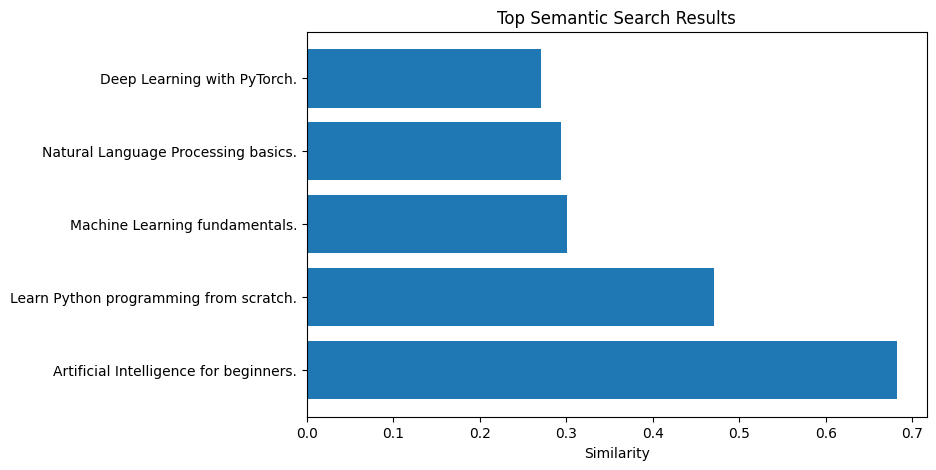

In [9]:
import matplotlib.pyplot as plt

top_results = results.head(5)

plt.figure(figsize=(8, 5))

plt.barh(top_results["Document"], top_results["Similarity"])

plt.xlabel("Similarity")

plt.title("Top Semantic Search Results")

plt.show()

In [10]:
def semantic_search(query, documents, model, top_k=5):

    doc_embeddings = model.encode(documents)

    query_embedding = model.encode(query)

    similarities = cosine_similarity([query_embedding], doc_embeddings)[0]

    results = pd.DataFrame({"Document": documents, "Similarity": similarities})

    results = results.sort_values(by="Similarity", ascending=False)

    return results.head(top_k)

In [11]:
semantic_search(query="How do I study AI?", documents=documents, model=model, top_k=5)

,Document,Similarity
1,Artificial Intelligence for beginners.,0.552834
0,Learn Python programming from scratch.,0.328768
2,Machine Learning fundamentals.,0.310311
6,Natural Language Processing basics.,0.288892
3,Deep Learning with PyTorch.,0.193535


In [12]:
while True:

    query = input("\nEnter Query (or quit): ")

    if query.lower() == "quit":
        break

    results = semantic_search(query=query, documents=documents, model=model, top_k=5)

    print("\nTop Matches:\n")
    print(results)


Top Matches:

                                 Document  Similarity
3             Deep Learning with PyTorch.    0.531797
1  Artificial Intelligence for beginners.    0.444517
0  Learn Python programming from scratch.    0.336031
2          Machine Learning fundamentals.    0.333790
6     Natural Language Processing basics.    0.256021

Top Matches:

                                 Document  Similarity
1  Artificial Intelligence for beginners.    0.193467
6     Natural Language Processing basics.    0.186917
0  Learn Python programming from scratch.    0.168164
3             Deep Learning with PyTorch.    0.125788
2          Machine Learning fundamentals.    0.105112

Top Matches:

                                 Document  Similarity
0  Learn Python programming from scratch.    0.145556
4             Best pizza recipes at home.    0.117743
2          Machine Learning fundamentals.    0.086738
3             Deep Learning with PyTorch.    0.086400
6     Natural Language Processing bas

In [13]:
document_embeddings = model.encode(documents)


def fast_search(query, documents, embeddings, model, top_k=5):

    query_embedding = model.encode(query)

    scores = cosine_similarity([query_embedding], embeddings)[0]

    results = pd.DataFrame({"Document": documents, "Score": scores})

    return results.sort_values("Score", ascending=False).head(top_k)

In [14]:
fast_search(
    query="Learn NLP", documents=documents, embeddings=document_embeddings, model=model
)

,Document,Score
6,Natural Language Processing basics.,0.567038
1,Artificial Intelligence for beginners.,0.402059
3,Deep Learning with PyTorch.,0.320760
2,Machine Learning fundamentals.,0.310565
0,Learn Python programming from scratch.,0.256553
